# Wind Generation in AIB Countries

This notebook quantifies wind power generation across AIB (Association of Issuing Bodies) member countries using ENTSO-E actual generation data, and compares it to Guarantee of Origin (GO) issuance volumes.

## Imports

Load required libraries and the database query interface.

In [3]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))
from functions.sql_data import get_sql_query
import pandas as pd
import matplotlib.pyplot as plt

## Parameters

Define the set of AIB member countries $\mathcal{C}$, the subset participating in the EECS electricity scheme, curve identifiers for ENTSO-E wind production data (onshore and offshore), and file paths for AIB activity statistics.

In [4]:
aib_members = [
    'AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 
    'EE', 'ES', 'FI', 'FR', 'GE', 'GR', 'HR', 'HU', 'IE', 'IS', 
    'IT', 'LT', 'LU', 'LV', 'ME', 'MK', 'NL', 'NO', 'PT', 'RO', 
    'RS', 'SE', 'SI', 'SK', 'UA', 'XK'
]

aib_electricity_scheme_group = [
    'AT', 'BE', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
    'FR', 'GR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 
    'NL', 'NO', 'PT', 'RS', 'SE', 'SI', 'SK'
]

# File paths for AIB GO activity statistics
GO_STATS_PATH_1 = "../GO_All_Statistics_1.csv"
GO_STATS_PATH_2 = "../GO_All_Statistics_2.csv"

# Hardcoded ENTSO-E wind production curve IDs per zone/country and generation type.
# Countries with bidding zones (NO, DK) are listed by zone; IT uses regional curves summed.
WIND_CURVE_IDS: dict[str, dict[str, int | None]] = {
    "AT": {
        "onshore": 1000318275,    # ENTSOE-APG-WIND-ONSHORE-ACTUAL
        "offshore": 1000318283,   # ENTSOE-APG-WIND-OFFSHORE-ACTUAL
    },
    "BE": {
        "onshore": 1500029398,    # ENTSOE-POWER-PRODUCTION-ACTUAL-BE-WIND-ONSHORE-MW
        "offshore": 1500029397,   # ENTSOE-POWER-PRODUCTION-ACTUAL-BE-WIND-OFFSHORE-MW
    },
    "CH": {
        "onshore": 910000231,     # EntsoE-ActualGeneration-CH-WindOnshore
        "offshore": 1500029461,   # ENTSOE-POWER-PRODUCTION-ACTUAL-CH-WIND-OFFSHORE-MW
    },
    "CY": {
        "onshore": None,
        "offshore": None,
    },
    "CZ": {
        "onshore": 910003006,     # ENTSOE_ActualGeneration_CZ_WIND-ONSHORE__PROD
        "offshore": 1500029493,   # ENTSOE-POWER-PRODUCTION-ACTUAL-CZ-WIND-OFFSHORE-MW
    },
    "DE": {
        "onshore": 1000318274,    # ENTSOE-DE-WIND-ONSHORE-ACTUAL (national)
        "offshore": 1000318282,   # ENTSOE-DE-WIND-OFFSHORE-ACTUAL (national)
    },
    "DK1": {
        "onshore": 1000318280,    # ENTSOE-DK1-WIND-ONSHORE-ACTUAL
        "offshore": 1000318288,   # ENTSOE-DK1-WIND-OFFSHORE-ACTUAL
    },
    "DK2": {
        "onshore": 1000318281,    # ENTSOE-DK2-WIND-ONSHORE-ACTUAL
        "offshore": 1000318289,   # ENTSOE-DK2-WIND-OFFSHORE-ACTUAL
    },
    "EE": {
        "onshore": 1500028969,    # ENTSOE-POWER-PRODUCTION-ACTUAL-EE-WIND-ONSHORE-MW
        "offshore": 1500028966,   # ENTSOE-POWER-PRODUCTION-ACTUAL-EE-WIND-OFFSHORE-MW
    },
    "ES": {
        "onshore": 910000225,     # EntsoE-ActualGeneration-ES-WindOnshore
        "offshore": 910000224,    # EntsoE-ActualGeneration-ES-WindOffshore
    },
    "FI": {
        "onshore": 1500019439,    # ENTSOE-POWER-PRODUCTION-ACTUAL-FI-WIND-ONSHORE-MW
        "offshore": 1500019432,   # ENTSOE-POWER-PRODUCTION-ACTUAL-FI-WIND-OFFSHORE-MW
    },
    "FR": {
        "onshore": 1000318278,    # ENTSOE-RTE-WIND-ONSHORE-ACTUAL
        "offshore": 1000318286,   # ENTSOE-RTE-WIND-OFFSHORE-ACTUAL
    },
    "GR": {
        "onshore": 910003087,     # ENTSOE_ActualGeneration_GR_WIND-ONSHORE__PROD
        "offshore": None,
    },
    "HR": {
        "onshore": 910004527,     # ENTSOE_ACTUAL-GENERATION_HR_WIND-ONSHORE_PROD
        "offshore": None,
    },
    "HU": {
        "onshore": 910003032,     # ENTSOE_ActualGeneration_HU_WIND-ONSHORE__PROD
        "offshore": None,
    },
    "IE": {
        "onshore": 910002524,     # EntsoE-ActualGeneration-IE-WindOnshore
        "offshore": None,
    },
    "IS": {
        "onshore": None,
        "offshore": None,
    },
    "IT_NORTH": {
        "onshore": 910000288,     # EntsoE-ActualGeneration-IT-NORTH-WindOnshore
        "offshore": 1500023502,   # ENTSOE-POWER-PRODUCTION-IT-NORTH-WIND-OFFSHORE-MW
    },
    "IT_CNOR": {
        "onshore": 910000262,     # EntsoE-ActualGeneration-IT-CNOR-WindOnshore
        "offshore": 1500023504,   # ENTSOE-POWER-PRODUCTION-IT-CNOR-WIND-OFFSHORE-MW
    },
    "IT_CSOUTH": {
        "onshore": 910000273,     # EntsoE-ActualGeneration-IT-CSOUTH-WindOnshore
        "offshore": 1500023503,   # ENTSOE-POWER-PRODUCTION-IT-CSOUTH-WIND-OFFSHORE-MW
    },
    "IT_SOUTH": {
        "onshore": 910000330,     # EntsoE-ActualGeneration-IT-SOUTH-WindOnshore
        "offshore": 1500023499,   # ENTSOE-POWER-PRODUCTION-IT-SOUTH-WIND-OFFSHORE-MW
    },
    "IT_SICILY": {
        "onshore": 910000322,     # EntsoE-ActualGeneration-IT-SICILY-WindOnshore
        "offshore": 1500023500,   # ENTSOE-POWER-PRODUCTION-IT-SICILY-WIND-OFFSHORE-MW
    },
    "IT_SARDINIA": {
        "onshore": 910000312,     # EntsoE-ActualGeneration-IT-SARDINIA-WindOnshore
        "offshore": 1500023501,   # ENTSOE-POWER-PRODUCTION-IT-SARDINIA-WIND-OFFSHORE-MW
    },
    "IT_CALABRIA": {
        "onshore": 1500023506,    # ENTSOE-POWER-PRODUCTION-IT-CALABRIA-WIND-ONSHORE-MW
        "offshore": 1500023507,   # ENTSOE-POWER-PRODUCTION-IT-CALABRIA-WIND-OFFSHORE-MW
    },
    "LT": {
        "onshore": 1500029109,    # ENTSOE-POWER-PRODUCTION-ACTUAL-LT-WIND-ONSHORE-MW
        "offshore": 1500029108,   # ENTSOE-POWER-PRODUCTION-ACTUAL-LT-WIND-OFFSHORE-MW
    },
    "LU": {
        "onshore": None,
        "offshore": None,
    },
    "LV": {
        "onshore": 1500029081,    # ENTSOE-POWER-PRODUCTION-ACTUAL-LV-WIND-ONSHORE-MW
        "offshore": 1500029080,   # ENTSOE-POWER-PRODUCTION-ACTUAL-LV-WIND-OFFSHORE-MW
    },
    "NL": {
        "onshore": 1000318276,    # ENTSOE-TENNET-WIND-ONSHORE-ACTUAL
        "offshore": 1000318284,   # ENTSOE-TENNET-WIND-OFFSHORE-ACTUAL
    },
    "NO1": {
        "onshore": 1500026496,    # ENTSOE-POWER-PRODUCTION-ACTUAL-NO1-WIND-ONSHORE-MW
        "offshore": 1500026495,   # ENTSOE-POWER-PRODUCTION-ACTUAL-NO1-WIND-OFFSHORE-MW
    },
    "NO2": {
        "onshore": 1500026538,    # ENTSOE-POWER-PRODUCTION-ACTUAL-NO2-WIND-ONSHORE-MW
        "offshore": 1500026537,   # ENTSOE-POWER-PRODUCTION-ACTUAL-NO2-WIND-OFFSHORE-MW
    },
    "NO3": {
        "onshore": 1500026580,    # ENTSOE-POWER-PRODUCTION-ACTUAL-NO3-WIND-ONSHORE-MW
        "offshore": 1500026579,   # ENTSOE-POWER-PRODUCTION-ACTUAL-NO3-WIND-OFFSHORE-MW
    },
    "NO4": {
        "onshore": 1500026622,    # ENTSOE-POWER-PRODUCTION-ACTUAL-NO4-WIND-ONSHORE-MW
        "offshore": 1500026621,   # ENTSOE-POWER-PRODUCTION-ACTUAL-NO4-WIND-OFFSHORE-MW
    },
    "NO5": {
        "onshore": 1500026664,    # ENTSOE-POWER-PRODUCTION-ACTUAL-NO5-WIND-ONSHORE-MW
        "offshore": 1500026663,   # ENTSOE-POWER-PRODUCTION-ACTUAL-NO5-WIND-OFFSHORE-MW
    },
    "PT": {
        "onshore": 910000344,     # EntsoE_ActualGeneration_PT_WindOnshore_PROD
        "offshore": 1500023370,   # ENTSOE-POWER-PRODUCTION-ACTUAL-PT-WIND-OFFSHORE-MW
    },
    "RS": {
        "onshore": None,
        "offshore": None,
    },
    "SE": {
        "onshore": 1500029525,    # ENTSOE-POWER-PRODUCTION-ACTUAL-SE-WIND-ONSHORE-MW
        "offshore": 1500029523,   # ENTSOE-POWER-PRODUCTION-ACTUAL-SE-WIND-OFFSHORE-MW
    },
    "SI": {
        "onshore": 910003062,     # ENTSOE_ActualGeneration_SI_WIND-ONSHORE__PROD
        "offshore": None,
    },
    "SK": {
        "onshore": 910003020,     # ENTSOE_ActualGeneration_SK_WIND-ONSHORE__PROD
        "offshore": None,
    },
}

# Zone-to-country mapping for aggregation
zone_to_country = {
    'NO1': 'NO', 'NO2': 'NO', 'NO3': 'NO', 'NO4': 'NO', 'NO5': 'NO',
    'DK1': 'DK', 'DK2': 'DK',
    'IT_NORTH': 'IT', 'IT_CNOR': 'IT', 'IT_CSOUTH': 'IT', 'IT_SOUTH': 'IT',
    'IT_SICILY': 'IT', 'IT_SARDINIA': 'IT', 'IT_CALABRIA': 'IT',
}


## Data Collection

We query the ENTSO-E wind production curves from the database. Each curve represents actual wind generation (MW) for a specific country/zone and type (onshore/offshore). The data is resampled to hourly granularity where needed, deduplicated by keeping the latest forecast revision, and aggregated per country.

In [5]:
# Build wind_curves DataFrame from the dictionary
records = []
for zone_or_country, types in WIND_CURVE_IDS.items():
    country = zone_to_country.get(zone_or_country, zone_or_country)
    zone = zone_or_country if zone_or_country in zone_to_country else None
    for gen_type, curve_id in types.items():
        if curve_id is None:
            continue
        records.append({
            'CurveId': curve_id,
            'CountryCode': country,
            'GenerationType': gen_type,
            'Zone': zone,
        })

wind_curves = pd.DataFrame(records)

print(f"Selected {len(wind_curves)} curves across {wind_curves['CountryCode'].nunique()} countries")
print(f"\nCountries: {sorted(wind_curves['CountryCode'].unique())}")
print(f"\nCurves per country and type:")
print(wind_curves.groupby(['CountryCode', 'GenerationType']).size().unstack(fill_value=0))
display(wind_curves)

Selected 62 curves across 23 countries

Countries: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'SE', 'SI', 'SK']

Curves per country and type:
GenerationType  offshore  onshore
CountryCode                      
AT                     1        1
BE                     1        1
CH                     1        1
CZ                     1        1
DE                     1        1
DK                     2        2
EE                     1        1
ES                     1        1
FI                     1        1
FR                     1        1
GR                     0        1
HR                     0        1
HU                     0        1
IE                     0        1
IT                     7        7
LT                     1        1
LV                     1        1
NL                     1        1
NO                     5        5
PT                     1        1
SE                     1        

,CurveId,CountryCode,GenerationType,Zone
0,1000318275,AT,onshore,None
1,1000318283,AT,offshore,None
2,1500029398,BE,onshore,None
3,1500029397,BE,offshore,None
4,910000231,CH,onshore,None
...,...,...,...,...
57,1500023370,PT,offshore,None
58,1500029525,SE,onshore,None
59,1500029523,SE,offshore,None
60,910003062,SI,onshore,None


In [6]:
available_wind_countries = sorted(wind_curves['CountryCode'].unique())

print("Countries with wind generation data:", available_wind_countries)
print("Number of countries with wind generation data:", len(available_wind_countries))
print("Countries without wind generation data:", sorted(set(aib_electricity_scheme_group) - set(available_wind_countries)))

Countries with wind generation data: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'SE', 'SI', 'SK']
Number of countries with wind generation data: 23
Countries without wind generation data: ['CY', 'IS', 'LU', 'RS']


In [7]:
def resample_generation_data(df, granularity='h'):
    df = df.resample('15min').ffill()
    df = df.resample(granularity).mean()
    return df

def get_curve_data(curve_id, granularity='h'):
    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {curve_id}
        AND ValueDateUTC >= '2021-01-01'
    """

    data = get_sql_query(country_query)
    data = data.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    data['ValueDateUTC'] = pd.to_datetime(data['ValueDateUTC'])
    data = data.set_index('ValueDateUTC').sort_index()
    data = data.drop(columns=['ForecastDateUTC'])

    resampled = resample_generation_data(data['Value'], granularity=granularity)
    return resampled

onshore_generation = {}
offshore_generation = {}

for country_code in available_wind_countries:
    onshore_ids = wind_curves[
        (wind_curves['CountryCode'] == country_code) & 
        (wind_curves['GenerationType'] == 'onshore')
    ]['CurveId'].values

    offshore_ids = wind_curves[
        (wind_curves['CountryCode'] == country_code) & 
        (wind_curves['GenerationType'] == 'offshore')
    ]['CurveId'].values

    # Onshore
    if len(onshore_ids) > 0:
        onshore_data = {}
        for curve_id in onshore_ids:
            print(f"Fetching onshore curve {curve_id} for {country_code}")
            onshore_data[curve_id] = get_curve_data(curve_id)
        onshore_generation[country_code] = pd.DataFrame(onshore_data).sum(axis=1)

    # Offshore
    if len(offshore_ids) > 0:
        offshore_data = {}
        for curve_id in offshore_ids:
            print(f"Fetching offshore curve {curve_id} for {country_code}")
            offshore_data[curve_id] = get_curve_data(curve_id)
        offshore_generation[country_code] = pd.DataFrame(offshore_data).sum(axis=1)

# Build DataFrames with countries as columns, hourly datetime as index
df_onshore = pd.DataFrame(onshore_generation)
df_offshore = pd.DataFrame(offshore_generation)
df_total = df_onshore.fillna(0).add(df_offshore.fillna(0), fill_value=0)

# Only keep columns that have data
df_onshore = df_onshore.dropna(axis=1, how='all')
df_offshore = df_offshore.dropna(axis=1, how='all')

print(f"\nOnshore: {df_onshore.shape[1]} countries, Offshore: {df_offshore.shape[1]} countries, Total: {df_total.shape[1]} countries")
display(df_total)

Fetching onshore curve 1000318275 for AT
Fetching offshore curve 1000318283 for AT
Fetching onshore curve 1500029398 for BE
Fetching offshore curve 1500029397 for BE
Fetching onshore curve 910000231 for CH
Fetching offshore curve 1500029461 for CH
Fetching onshore curve 910003006 for CZ
Fetching offshore curve 1500029493 for CZ
Fetching onshore curve 1000318274 for DE
Fetching offshore curve 1000318282 for DE
Fetching onshore curve 1000318280 for DK
Fetching onshore curve 1000318281 for DK
Fetching offshore curve 1000318288 for DK
Fetching offshore curve 1000318289 for DK
Fetching onshore curve 1500028969 for EE
Fetching offshore curve 1500028966 for EE
Fetching onshore curve 910000225 for ES
Fetching offshore curve 910000224 for ES
Fetching onshore curve 1500019439 for FI
Fetching offshore curve 1500019432 for FI
Fetching onshore curve 1000318278 for FR
Fetching offshore curve 1000318286 for FR
Fetching onshore curve 910003087 for GR
Fetching onshore curve 910004527 for HR
Fetching on

/var/folders/9z/lz_ys39936g9hjq8wmdvgm080000gn/T/ipykernel_30082/3385654760.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_total = df_onshore.fillna(0).add(df_offshore.fillna(0), fill_value=0)


,AT,BE,CH,CZ,DE,DK,EE,ES,FI,FR,...,IE,IT,LT,LV,NL,NO,PT,SE,SI,SK
ValueDateUTC,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,117.0,0,15.000000,65.0000,3931.000000,549.00000,29.100,7001.0,402.0,1075.000,...,2083.0,2801.00,2.190000,3.0,349.50000,703.000000,2837.0,978.00000,0.00000,0.000
2021-01-01 01:00:00,73.0,0,11.000000,57.0000,3509.750000,493.00000,24.900,7256.0,374.0,1086.000,...,2096.0,2673.00,1.600000,1.0,388.25000,732.000000,2653.0,913.00000,0.00000,0.000
2021-01-01 02:00:00,82.0,0,9.000000,76.0000,3094.250000,429.00000,20.400,7951.0,366.0,1149.000,...,2146.5,2671.00,0.400000,1.0,407.25000,753.000000,2469.0,914.00000,0.00000,1.000
2021-01-01 03:00:00,75.0,0,4.000000,70.0000,2765.500000,353.00000,22.800,8791.0,366.0,1170.000,...,2046.0,2654.00,0.100000,1.0,463.50000,751.000000,2382.0,959.00000,1.00000,1.000
2021-01-01 04:00:00,65.0,0,4.000000,58.0000,2556.750000,301.00000,23.300,9209.0,402.0,1190.000,...,2038.5,2521.00,0.010000,0.0,489.50000,745.000000,2241.0,996.00000,1.00000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-09 03:00:00,314.0,0,24.379999,97.8925,25148.315735,2755.38875,75.900,8100.0,0.0,5900.670,...,0.0,1016.75,40.828221,12.0,2443.47425,870.731482,2014.3,2089.74175,0.00000,0.125
2026-06-09 04:00:00,226.0,0,25.079999,103.2925,24834.002805,2594.71975,68.800,8088.0,0.0,5384.485,...,0.0,1027.25,21.044761,28.0,2245.50175,926.265547,2188.4,1947.43300,0.20748,0.000
2026-06-09 05:00:00,101.0,0,24.149999,82.9550,23402.876583,2470.28100,98.775,8047.0,0.0,4758.690,...,0.0,838.75,10.579744,35.0,1783.09625,1142.447061,2290.2,1830.74775,0.53100,0.000


## Wind Generation Overview

The following plots show monthly average onshore, offshore, and total wind generation across the 12 available countries (AT, BE, CH, CZ, DE, DK, FR, LT, LV, NL, NO, SE). The remaining AIB member countries do not have wind generation curves available in our ENTSO-E database.

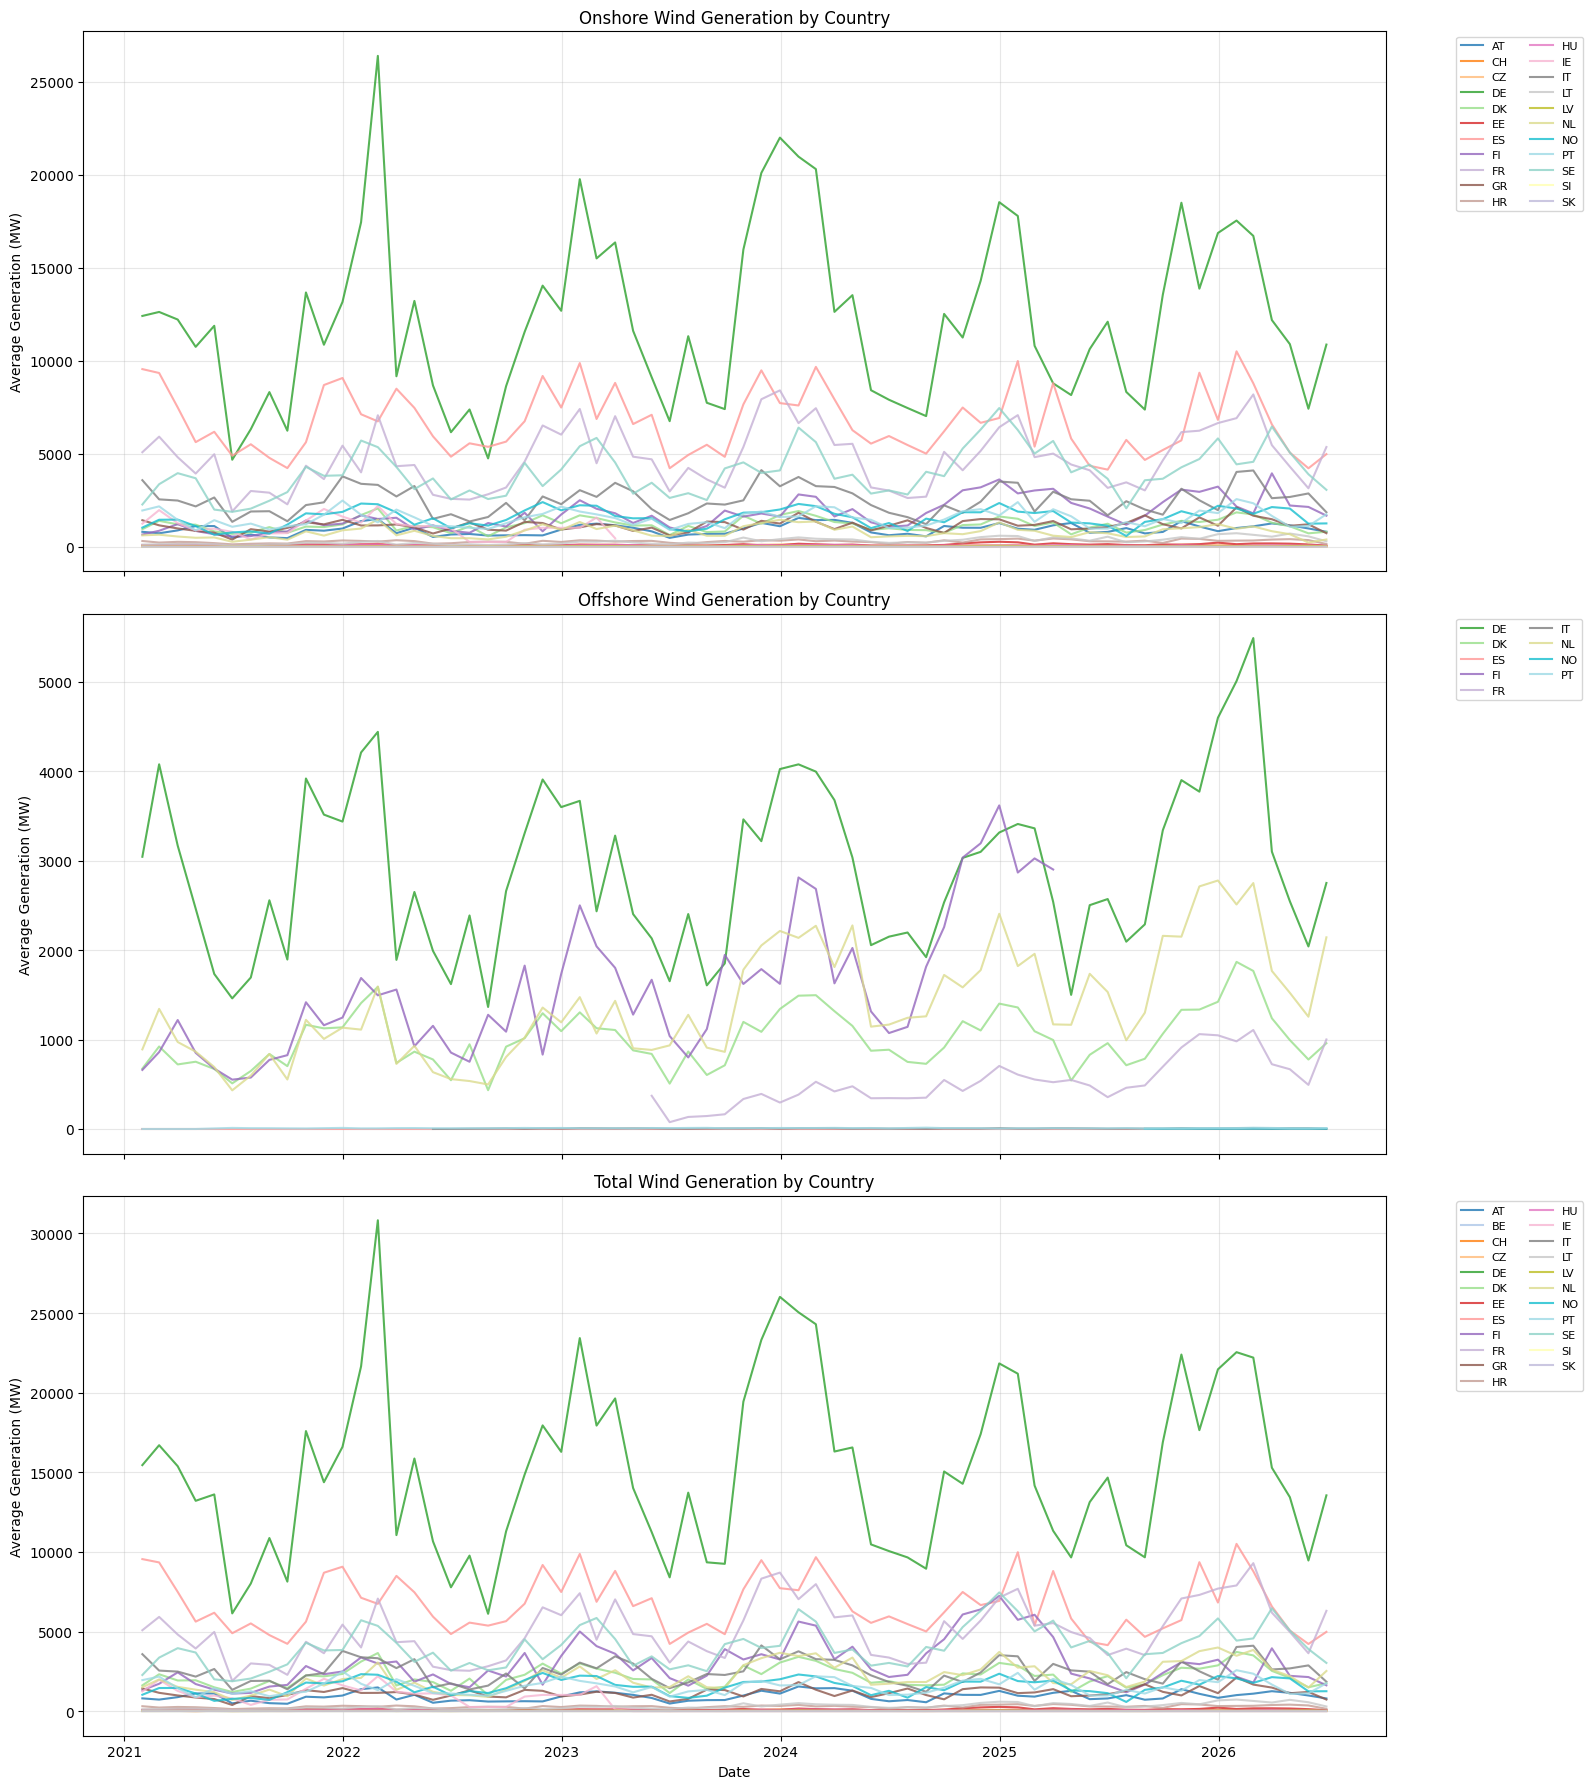

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# Assign consistent colors to all countries
all_countries = sorted(df_total.columns)
_colors = (plt.cm.tab20.colors[:20] + plt.cm.Set3.colors[:7])
country_colors = {country: _colors[i % len(_colors)] for i, country in enumerate(all_countries)}

# Onshore
monthly_onshore = df_onshore.resample('ME').mean()
for country in sorted(monthly_onshore.columns):
    axes[0].plot(monthly_onshore.index, monthly_onshore[country], label=country, alpha=0.8, color=country_colors[country])
axes[0].set_ylabel('Average Generation (MW)')
axes[0].set_title('Onshore Wind Generation by Country')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
axes[0].grid(True, alpha=0.3)

# Offshore
monthly_offshore = df_offshore.resample('ME').mean()
for country in sorted(monthly_offshore.columns):
    axes[1].plot(monthly_offshore.index, monthly_offshore[country], label=country, alpha=0.8, color=country_colors[country])
axes[1].set_ylabel('Average Generation (MW)')
axes[1].set_title('Offshore Wind Generation by Country')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
axes[1].grid(True, alpha=0.3)

# Total
monthly_total = df_total.resample('ME').mean()
for country in sorted(monthly_total.columns):
    axes[2].plot(monthly_total.index, monthly_total[country], label=country, alpha=0.8, color=country_colors[country])
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Generation (MW)')
axes[2].set_title('Total Wind Generation by Country')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison with GO Issuances

We compare ENTSO-E actual wind generation (converted to MWh) with GO issuance data from AIB statistics. The GO data is filtered for electricity certificates with wind as the energy source. Monthly generation is matched to monthly GO issuance by country.

In [9]:
df_1 = pd.read_csv(GO_STATS_PATH_1, sep=",")
df_2 = pd.read_csv(GO_STATS_PATH_2, sep=",")
go_df = pd.concat([df_1, df_2], ignore_index=True)

display(go_df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


In [10]:
# Only consider energy carrier electricity and source wind
wind_go_df = go_df[go_df['energy_carrier'].str.contains('Electricity') & go_df['energy_source_level2'].str.contains('Wind')].copy()

# Classification columns
wind_go_df['year'] = pd.to_datetime(wind_go_df['year_month_date']).dt.year
wind_go_df['month'] = pd.to_datetime(wind_go_df['year_month_date']).dt.month
wind_go_df['country_code'] = wind_go_df['domain_name'].str.split(' ').str[0].astype(str)
wind_go_df['energy_source'] = wind_go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

# Remove redundant columns
wind_go_df.drop(columns=['year_month_date', 'month_name', 'domain_name', 'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'], inplace=True)

# Columns reordering
wind_go_df = wind_go_df[['year', 'month', 'country_code', 'energy_source'] + wind_go_df.columns[1:11].tolist()]

# Remove incomplete last month (likely partial data)
last_year = wind_go_df['year'].max()
last_month = wind_go_df[wind_go_df['year'] == last_year]['month'].max()
wind_go_df = wind_go_df[(wind_go_df['year'] >= 2020) & ~((wind_go_df['year'] == last_year) & (wind_go_df['month'] == last_month))]

# Sorting and resetting index
wind_go_df = wind_go_df.sort_values(by=['year', 'month', 'country_code']).reset_index(drop=True)

display(wind_go_df)

,year,month,country_code,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2020,1,AT,Wind,0,0,0,0,0,3804,3804,0,0,0
1,2020,1,AT,Wind,394915,0,422445,94761,0,63006,7331,753815,304093,0
2,2020,1,BE,Wind,0,0,632416,0,0,0,0,527096,557704,0
3,2020,1,BEB,Wind,0,0,0,8850,0,0,0,0,8850,0
4,2020,1,BEB,Wind,11001,0,0,29924,0,6309,0,0,29924,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5212,2026,3,SE,Wind,0,0,35182,717319,0,0,548545,50219,656,0
5213,2026,3,SI,Wind,0,0,0,22719,0,0,22719,0,0,0
5214,2026,3,SK,Wind,0,0,0,3995,0,0,93331,0,0,0
5215,2026,3,SK,Wind,0,0,0,6004,0,0,0,0,0,0


In [14]:
# Monthly GO issuance (MWh) by country
go_issued = wind_go_df.groupby(['year', 'month', 'country_code'])['production_date_issue'].sum().reset_index()
go_issued.columns = ['year', 'month', 'country_code', 'go_issued_mwh']
go_issued['date'] = pd.to_datetime(go_issued[['year', 'month']].assign(day=1))

# Monthly ENTSO-E generation (MW hourly -> MWh by summing hourly values)
monthly_gen_mwh = df_total.resample('ME').sum()  # sum of hourly MW = MWh

# Reshape to long format for comparison
gen_long = monthly_gen_mwh.reset_index().melt(id_vars='ValueDateUTC', var_name='country_code', value_name='entsoe_mwh')
gen_long['year'] = gen_long['ValueDateUTC'].dt.year
gen_long['month'] = gen_long['ValueDateUTC'].dt.month

# Merge GO issuance with ENTSO-E generation
comparison = gen_long.merge(go_issued, on=['year', 'month', 'country_code'], how='outer')
comparison['date'] = pd.to_datetime(comparison[['year', 'month']].assign(day=1))
comparison = comparison.sort_values(['country_code', 'date'])

# GO issuance rate (% of generation that got GOs issued)
comparison['go_rate'] = (comparison['go_issued_mwh'] / comparison['entsoe_mwh']) * 100

# Filtering and resetting index
comparison = comparison[['date', 'country_code', 'entsoe_mwh', 'go_issued_mwh', 'go_rate']].dropna(subset=['entsoe_mwh', 'go_issued_mwh']).reset_index(drop=True)

display(comparison)

,date,country_code,entsoe_mwh,go_issued_mwh,go_rate
0,2021-01-01,AT,598647.0,574505.0,95.967239
1,2021-02-01,AT,488653.0,464677.0,95.093451
2,2021-03-01,AT,655386.0,599568.0,91.483187
3,2021-04-01,AT,802042.0,728800.0,90.868059
4,2021-05-01,AT,828097.0,783739.0,94.643381
...,...,...,...,...,...
1416,2025-11-01,SK,454.3,452.0,99.493727
1417,2025-12-01,SK,266.5,263.0,98.686679
1418,2026-01-01,SK,541.2,534.0,98.669623
1419,2026-02-01,SK,408.3,0.0,0.000000


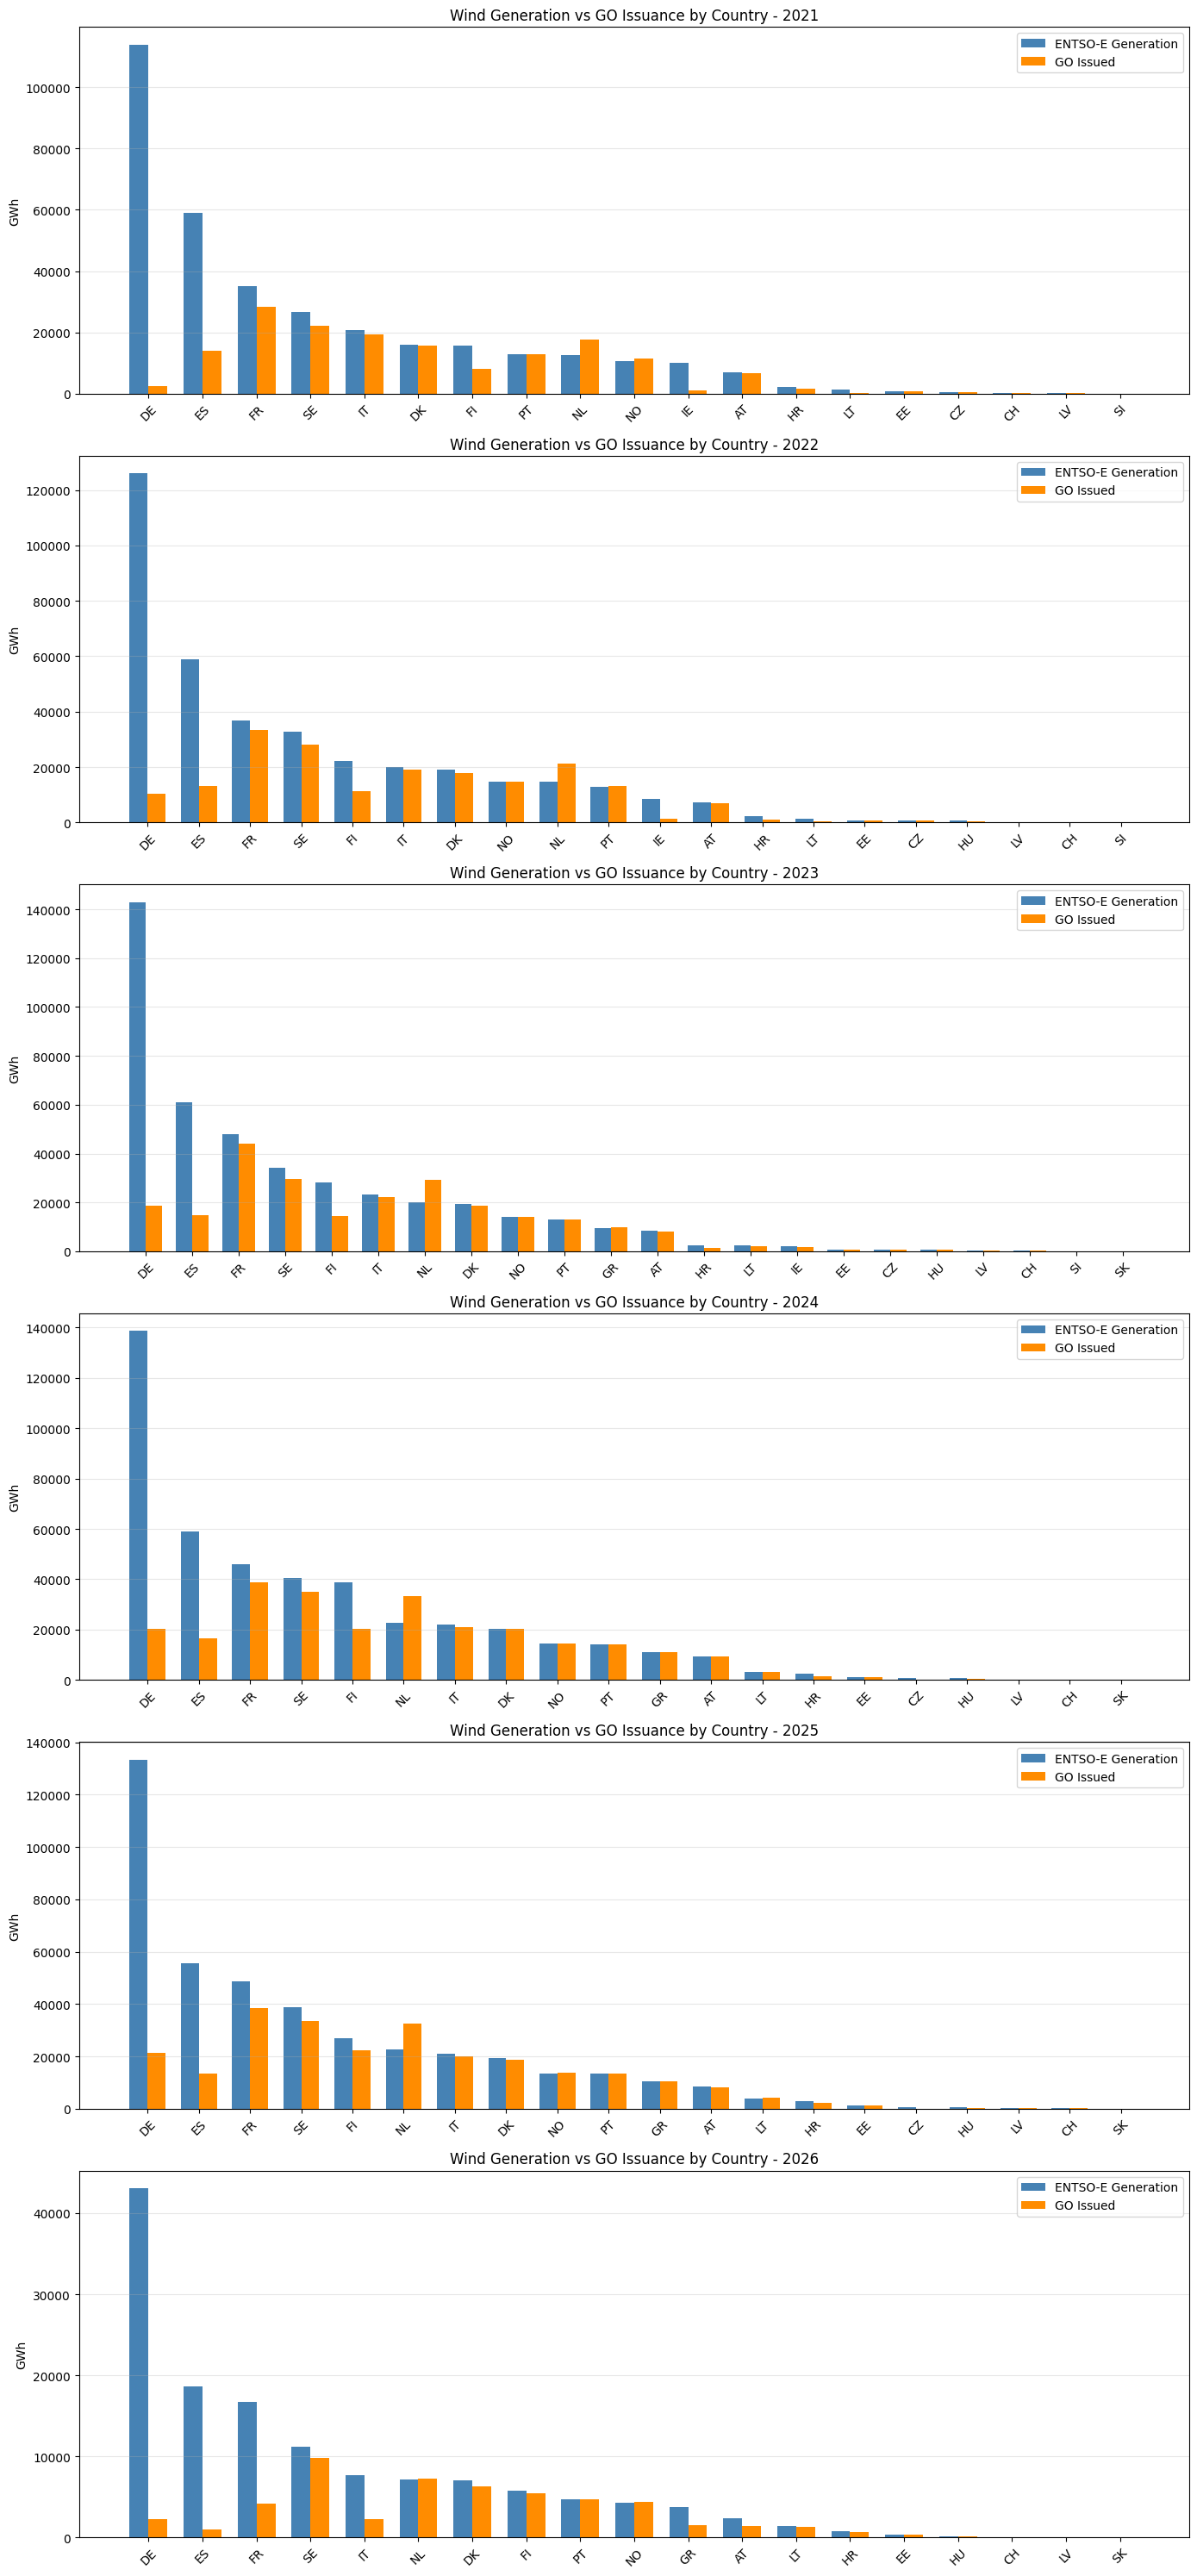

In [15]:
# Plot comparison: annual totals by country
annual = comparison.groupby(['country_code', comparison['date'].dt.year]).agg(
    entsoe_gwh=('entsoe_mwh', lambda x: x.sum() / 1e3),
    go_issued_gwh=('go_issued_mwh', lambda x: x.sum() / 1e3)
).reset_index()
annual.columns = ['country_code', 'year', 'entsoe_gwh', 'go_issued_gwh']

# Filter to countries present in both datasets and year 2021+
annual = annual[(annual['entsoe_gwh'] > 0) & (annual['go_issued_gwh'] > 0) & (annual['year'] >= 2021)]

# Plot per year
years = sorted(annual['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)))

for i, year in enumerate(years):
    ax = axes[i] if len(years) > 1 else axes
    year_data = annual[annual['year'] == year].sort_values('entsoe_gwh', ascending=False)
    
    x = range(len(year_data))
    width = 0.35
    ax.bar([p - width/2 for p in x], year_data['entsoe_gwh'], width, label='ENTSO-E Generation', color='steelblue')
    ax.bar([p + width/2 for p in x], year_data['go_issued_gwh'], width, label='GO Issued', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(year_data['country_code'], rotation=45)
    ax.set_ylabel('GWh')
    ax.set_title(f'Wind Generation vs GO Issuance by Country - {year}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## GO Issuance Factors & 2026 Estimation

Calculate the average ratio of GO issuance to ENTSO-E generation per country (2021–2025), then apply these factors to 2026 generation to estimate expected GO volumes not yet issued.

In [16]:
# Pending GO issuance per production year
# Approach: use 2022-2024 as "settled benchmark" years (fully past the 12-month issuance window).
# For each country, compute the aggregate GO factor (sum of production_date_issue / sum of ENTSO-E gen)
# over those years. Apply this factor to each year's ENTSO-E generation to get expected total GOs.
# Pending = expected - actual production_date_issue (clipped at 0).
# Note: by construction 2022-2024 net to ~0 pending. 2021 reflects how that year's coverage compares
# to the 2022-2024 average. 2025-2026 reflect timing-related pending issuance still within the window.

historical = annual[(annual['year'] >= 2021) & (annual['year'] <= 2025)].copy()

settled_factors = historical[historical['year'].between(2022, 2024)].groupby('country_code').apply(
    lambda g: g['go_issued_gwh'].sum() / g['entsoe_gwh'].sum(), include_groups=False
)

print("Settled GO Issuance Factor by Country (2022-2024 aggregate)")
print("Factor = sum(GO Issued) / sum(ENTSO-E Generation)")
print("=" * 65)
display(settled_factors.round(3).rename('settled_factor').to_frame())

pending_per_year = annual.copy()
pending_per_year['settled_factor'] = pending_per_year['country_code'].map(settled_factors)
pending_per_year['expected_go_gwh'] = pending_per_year['entsoe_gwh'] * pending_per_year['settled_factor']

# Aggregate first, then clip at the year level so countries with issued > expected (e.g. NL)
# offset countries with issued < expected, rather than being floored to zero per-country.
pending_by_year = pending_per_year.groupby('year').agg(
    entsoe_gwh=('entsoe_gwh', 'sum'),
    expected_gwh=('expected_go_gwh', 'sum'),
    issued_gwh=('go_issued_gwh', 'sum'),
).round(0)
pending_by_year['pending_gwh'] = (pending_by_year['expected_gwh'] - pending_by_year['issued_gwh']).clip(lower=0)
pending_by_year['pct_issued'] = (pending_by_year['issued_gwh'] / pending_by_year['expected_gwh'] * 100).round(1)

print(f"\nPending GO issuance by production year")
print(f"(Benchmark: 2022-2024 settled GO factor per country, applied to each year's ENTSO-E generation)")
print("=" * 75)
display(pending_by_year)

Settled GO Issuance Factor by Country (2022-2024 aggregate)
Factor = sum(GO Issued) / sum(ENTSO-E Generation)


,settled_factor
country_code,
AT,0.985
CH,1.062
CZ,0.632
DE,0.121
DK,0.968
EE,0.881
ES,0.250
FI,0.517
FR,0.889



Pending GO issuance by production year
(Benchmark: 2022-2024 settled GO factor per country, applied to each year's ENTSO-E generation)


,entsoe_gwh,expected_gwh,issued_gwh,pending_gwh,pct_issued
year,,,,,
2021,345678.0,181397.0,163472.0,17925.0,90.1
2022,379996.0,203013.0,194525.0,8488.0,95.8
2023,430792.0,239692.0,243842.0,0.0,101.7
2024,445855.0,256749.0,261086.0,0.0,101.7
2025,422182.0,245743.0,254915.0,0.0,103.7
2026,135191.0,79216.0,53443.0,25773.0,67.5


## Conclusion

The comparison between ENTSO-E wind generation and GO issuance across 12 countries reveals significant country-level differences driven by regulatory and structural factors:

**Germany (DE):** Despite being Europe's largest wind power producer, GO issuance is very low. This is due to the *Doppelvermarktungsverbot* (double marketing prohibition) under the EEG — generators receiving feed-in tariffs or market premiums cannot simultaneously obtain GOs. Since the vast majority of German wind capacity was built under EEG support, those installations are excluded from the GO system. Germany is consequently a large net importer of GOs despite its abundant domestic wind generation. This gap is expected to narrow as older turbines exit their 20-year EEG support period and new capacity is increasingly built on a merchant/PPA basis.

**Netherlands (NL):** The only country where GO issuance consistently exceeds measured ENTSO-E generation. This discrepancy arises because ENTSO-E data only captures TSO-visible generation (TenneT NL), while many Dutch onshore wind farms are connected at the distribution level (Liander, Enexis, Stedin). These DSO-connected installations are invisible to ENTSO-E but are fully eligible for GO issuance through VertiCer. The GO data therefore provides a more complete picture of actual Dutch wind generation.

**Nordic countries (NO, SE):** Show a close match between generation and GO issuance, consistent with well-established GO markets and comprehensive TSO reporting.

**Well-covered Western European markets (BE, DK, FR):** Generation and GO issuance align closely. Single-TSO countries with complete national coverage and no EEG-style restrictions. Minor differences are attributable to GO issuance timing (up to 12 months after production) and small DSO-connected capacity.

**Smaller markets (AT, CH, CZ, LT, LV):** Also show a close alignment, as expected in countries with single TSOs providing complete national coverage and without double marketing restrictions.

**Pending GO issuance:** By 2026, wind GOs are largely issued in near-real time. The dominant wind-producing countries (DE, ES, NL, FR, BE, DK) operate registries (HKN, CNMC, VertiCer, EEX, Energinet) where issuance typically lags production by only 1–2 months, driven by monthly PPA settlement cycles. As a result, the 2022–2024 settled benchmark indicates virtually no pending issuance for 2025 production by mid-2026 — essentially all 2025 wind GOs are already in the registry. The meaningful pending volume is concentrated in 2026 (year-to-date production not yet processed).
